In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cvxpy as cp
import time
import pathlib

from scripts import power_system_simulation as sim

base_dir = pathlib.Path(".")
system_dir = base_dir / "RTS-GMLC-master" / "RTS_Data"
results_dir = base_dir / "results"

### Simulating Power System with 2001-2019 Data

In [7]:
# Instantiate system
system = sim.System(
    base_dir,
    system_dir,
    "Modified-Config"
)

# Make results directory for system configuration
results_config_dir = results_dir / system.system_config
results_config_dir.mkdir(parents=True, exist_ok=True)

# Simulate all years
start = time.time()
for year in range(2001, 2020):
    results, LMPs = system.simulate_year(year)
    results.to_csv(results_config_dir / f"results_{year}.csv")
    LMPs.to_csv(results_config_dir / f"LMPs_{year}.csv")
end = time.time()
print(f"Total time elapsed: {(end - start)/60:.2f} minutes")

Total time elapsed: 15.18 minutes


In [21]:
# Results analysis
system_config = "Modified-Config"
results_config_dir = results_dir / system_config
for year in range(2001, 2020):
    results = pd.read_csv(results_config_dir / f"results_{year}.csv", index_col=[0])
    results.index = pd.to_datetime(results.index)
    #print((results["Unserved Energy"] > 0).sum())

### Analyzing 2006 Dispatch Results

In [8]:
# Instantiate system
system = sim.System(
    base_dir,
    system_dir,
    "Modified-Config"
)

results, LMPs = system.simulate_year(2006)

2006-12-13 00:00:00


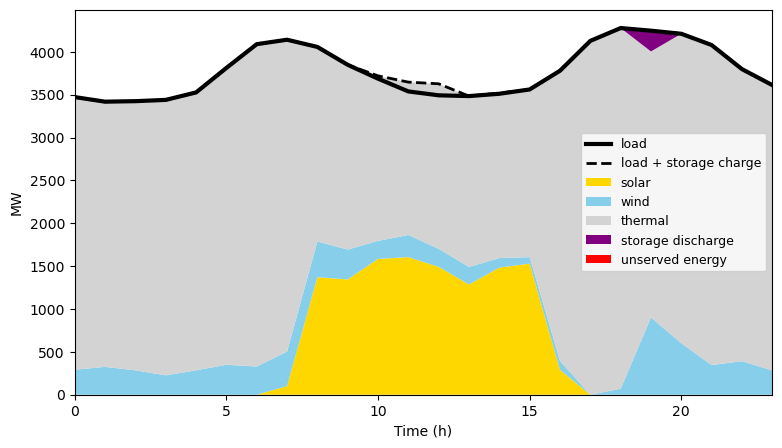

In [22]:
system.solve_opf(pd.Timestamp(year=2006, month=12, day=13))
print(system.opf_date)
df_dispatch = system.dispatch_results
system.dispatch_plot(df_dispatch)

### Benchmarking / Comparison with RTS GMLC System (2006 Weather Year)

In [ ]:
# 1. Instantiate system
system = sim.System(base_dir, system_dir, "RTS-GMLC-Config")

print(sum(resource.pmax for resource in system.thermal_resources.values()))

# 2. Read in time series for a particular year
year = 2006
system.read_timeseries(year)

# 3. Create model
system.write_opf()

In [ ]:
print(8076.0 - 7385.0)

In [ ]:
### Reliability Simulation ###

# Simulate each day in data set
df_results = pd.DataFrame(index=pd.date_range(f"{year}-01-01 00:00:00", f"{year}-12-31 23:59:59", freq="h"), columns=["Cost", "Unserved Energy"])
df_LMP = pd.DataFrame(index=df_results.index, columns=list(system.nodes.keys()))
start = time.time()
for date in df_results.index[::sim.T]:
    if date + pd.Timedelta(hours=sim.T) > df_results.index.max():
        break
    
    # Re-solve model
    system.solve_opf(date)

    # Save results
    df_results.loc[date, "Cost"] = system.total_variable_costs.value
    df_results.loc[date, "Unserved Energy"] = cp.sum(cp.sum([n.unserved_energy for n in system.nodes.values()])).value
    for n in system.nodes.keys():
        df_LMP.loc[date:date + pd.Timedelta(hours=sim.T-1), n] = system.nodes[n].power_balance_constraint.dual_value
        
        
end = time.time()
time_elapsed = end - start
print(f"Total Elapsed Time: {time_elapsed:.1f}s")

In [ ]:
df_results.dropna().mean()

In [ ]:
df_LMP.mean(axis=1).plot()

In [ ]:
df_LMP[df_LMP.max(axis=0).idxmax()].plot()

In [ ]:
df_results["Cost"][::24].plot()

In [ ]:
agg_load = 0
for node in system.nodes.values():
    agg_load += node.peak_load * node.load_profile

In [ ]:
# System-wide aggregated load
agg_load.plot()

In [ ]:
agg_load.shift(-8).groupby(agg_load.index.hour).mean().plot()

In [ ]:
agg_load_gmlc = pd.read_csv("RTS-GMLC_aggregate_load.csv", index_col=[0]) # Obtained from other reliability_simulation.ipynb notebook...

In [ ]:
# Quantile-Quantile Plot
quantiles = np.linspace(0, 1, 26)
load_space = np.linspace(2500, 9000, 20)

plt.figure(figsize=(6,6))
plt.scatter(agg_load.quantile(quantiles), agg_load_gmlc.quantile(quantiles))
plt.plot(load_space, load_space, color="black")
plt.title("Q-Q Plot of Aggregated 2006 Load")
plt.xlabel("E2E-Downscale Quantile")
plt.ylabel("GMLC Quantile")
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
_, bins, _ = plt.hist(agg_load.values, bins=50, alpha=0.5, color="blue")
plt.hist(agg_load_gmlc.values, bins=bins, alpha=0.4, color="red")
plt.show()